In [2]:
from pandas import concat, read_csv

REGIONS = ('DE', 'DR', 'V')
CSV_COLUMNS = ('I', 'R', 'E', 'A', 'DE', 'DA', 'H', 'M')
NUMERIC_COLUMNS = ('DA', 'H', 'M')
converters = {
    col: lambda value: value.replace(',', '')
    for col in NUMERIC_COLUMNS
}
df = concat(
    (
        read_csv(
            f'R/{region}.csv',
            index_col='I',
            usecols=CSV_COLUMNS,
            converters=converters,
            na_filter=False
        )
        for region in REGIONS
    ),
    keys=REGIONS,
    names=('RE',)
)
df

R   E  A  DE    DA      H      M
RE I                                    
DE 1    T   0  0   8  2947   1425   4611
   1    D   1  0   3  1818      0    650
   1    D   2  0   7  4735    487    308
   1    S   1  0   3  2078   2748      0
   1    S   1  1   3   269   5848    189
...    ..  .. ..  ..   ...    ...    ...
V  491  T  12  1   9  7745     12  12986
   491  D   6  0  10  7838   1433      0
   491  D  12  2   8  8688      0    472
   491  S   2  8   7  1041  11310    256
   491  S   2  7   8  3005   8648    548

[9510 rows x 7 columns]

In [3]:
from string import digits

digit_dict = {'': 0, 'T': 1, 'D': 2, 'S': 3}
for i, d in enumerate(digits, 1):
    digit_dict[d] = i
digit_dict

{'': 0,
 'T': 1,
 'D': 2,
 'S': 3,
 '0': 1,
 '1': 2,
 '2': 3,
 '3': 4,
 '4': 5,
 '5': 6,
 '6': 7,
 '7': 8,
 '8': 9,
 '9': 10}

In [4]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].map(digit_dict).fillna(0).astype(uint8)
result_df = DataFrame(result)
result_df

R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  DA3  ...  H5  H4  H3  H2  H1  \
RE I                                                 ...                       
DE 1     1   0   1   0   1    0    9    0    3   10  ...   0   2   5   3   6   
   1     2   0   2   0   1    0    4    0    2    9  ...   0   0   0   0   1   
   1     2   0   3   0   1    0    8    0    5    8  ...   0   0   5   9   8   
   1     3   0   2   0   1    0    4    0    3    1  ...   0   3   8   5   9   
   1     3   0   2   0   2    0    4    0    0    3  ...   0   6   9   5   9   
...     ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  491   1   2   3   0   2    0   10    0    8    8  ...   0   0   0   2   3   
   491   2   0   7   0   1    2    1    0    8    9  ...   0   2   5   4   4   
   491   2   2   3   0   3    0    9    0    9    7  ...   0   0   0   0   1   
   491   3   0   3   0   9    0    8    0    2    1  ...   2   2   4   2   1   
   491   3   0   3   0   8    0    9    0    4    1  ...   0   9   7   5   9   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   5   7   2   2  
   1     0   0   7   6   1  
   1     0   0   4   1   9  
   1     0   0   0   0   1  
   1     0   0   2   9  10  
...     ..  ..  ..  ..  ..  
V  491   2   3  10   9   7  
   491   0   0   0   0   1  
   491   0   0   5   8   3  
   491   0   0   3   6   7  
   491   0   0   6   5   9  

[9510 rows x 22 columns]

In [5]:
result_df['E1'].value_counts()

E1
1     1032
2     1008
3      983
5      959
6      955
4      949
7      933
8      927
10     856
9      841
0       67
Name: count, dtype: int64

In [6]:
df_numpy = result_df.to_numpy().reshape(-1, 10, 22)
df_0, df_1 = df_numpy[:, :, 0], df_numpy[:, :, 1:]
df_0.shape, df_1.shape

((951, 10), (951, 10, 21))

In [7]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather

image_paths = sorted(map(str, Path().rglob('*.png')))
data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled_0 = gather(df_0, indices)
y_shuffled_1 = gather(df_1, indices)

train_size = int(data_count * .9)
train_X, val_X = X_shuffled[:train_size], X_shuffled[train_size:]
train_y_0, val_y_0 = y_shuffled_0[:train_size], y_shuffled_0[train_size:]
train_y_1, val_y_1 = y_shuffled_1[:train_size], y_shuffled_1[train_size:]
train_X.shape, train_y_0.shape, train_y_1.shape

I0000 00:00:1773047783.789932    7095 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


(TensorShape([819]), TensorShape([819, 10]), TensorShape([819, 10, 21]))

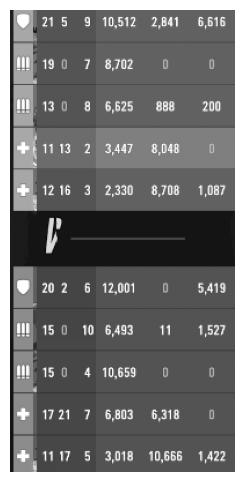

tf.Tensor(
[[ 1  3  5  0 10  0  6  2  3  9  4  5  0  0  0  0  1  2  3  3  3  3]
 [ 2  4  2  0  1  0  8  2  1  1  1  2  0  0  8  5  6  0  0  0  0  1]
 [ 2  4  6  0  1  0  7  2  4  9  6  6  0  0  0  0  1  0  3  6  6 10]
 [ 3  2 10  4  1  0  8  0  6  6  9  7  2  2  4  1 10  0  4  5  8  7]
 [ 3  2  7  2  8  0  8  0  4  4  6  8  2  1  2 10  8  0  0  3 10 10]
 [ 1  3  6  0  4  2  1  2  5  6 10  2  0  0  0  0  1  2  4  3  9  8]
 [ 2  2  4  0  4  0 10  0 10  1  3  8  0  0  0  9  5  0  0  6 10 10]
 [ 2  3  4  0  1  0  9  0  9 10  7  4  0  0  0  0  1  0  2  1  3 10]
 [ 3  0  8  2  9  2  2  0  4  7  7  7  2  1  1  6  3  0  0  3  4  9]
 [ 3  2  1  2  9  2  2  0  5  5  8 10  0 10 10  4  5  0  2  2  4  6]], shape=(10, 22), dtype=uint8)


2026-03-09 09:16:24.487542: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, {'output_1': train_y_0, 'output_2': train_y_1}, shuffle=False)
val_ds = make_dataset(val_X, {'output_1': val_y_0, 'output_2': val_y_1}, shuffle=False)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    y_expanded = tf.expand_dims(y_batch['output_1'], axis=-1)   # (32, 10, 1)
    y_result = tf.concat([y_expanded, y_batch['output_2']], axis=-1)
    print(y_result[0])

- Embedding 고려
- Positional Encoding 고려

In [24]:
from tensorflow.keras.backend import clear_session
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    BatchNormalization,
    Activation,
    Reshape,
    MultiHeadAttention,
    Add,
    LayerNormalization,
    Dense,
    TimeDistributed,
    Conv1D
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy


def build_model():
    inputs = Input((400, 194, 1))
    
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)
    
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)
    
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)
    
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)
    
    x = Conv2D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = Reshape((25, 12 * 64))(x)
    
    x = Dense(512)(x)
    
    attn = MultiHeadAttention(4, 128)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)
    
    ff = Dense(512, 'relu')(x)
    ff = Dense(512)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    seq1 = TimeDistributed(Dense(4, 'relu'))(x)
    out1 = Conv1D(4, 3, 3, 'same', activation='relu')(seq1)
    out1 = Reshape((10, 4))(out1)

    seq2 = TimeDistributed(Dense(231, 'relu'))(x)
    out2 = Conv1D(231, 3, 3, 'same', activation='relu')(seq2)
    out2 = Reshape((10, 21, 11))(out2)

    return Model(inputs, [out1, out2])


clear_session()
model = build_model()
model.compile(
    'adam',
    {
        'output_1': SparseCategoricalCrossentropy(True),
        'output_2': SparseCategoricalCrossentropy(True)
    },
    {'output_1': 0.2, 'output_2': 1.8},
    metrics={'output_1': 'sparse_categorical_accuracy', 'output_2': 'sparse_categorical_accuracy'}
)
model.summary()

ValueError: The total size of the tensor must be unchanged. Received: input_shape=(9, 4), target_shape=(10, 4)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=128,
    callbacks=EarlyStopping(patience=8, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/256


2026-03-09 09:12:25.968199: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-09 09:12:25.982959: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 3.1343 - output_1_loss: 0.4379 - output_1_sparse_categorical_accuracy: 0.8552 - output_2_loss: 1.9436 - output_2_sparse_categorical_accuracy: 0.3246

2026-03-09 09:12:37.442450: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-09 09:12:37.449995: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 623ms/step - loss: 2.7902 - output_1_loss: 0.3206 - output_1_sparse_categorical_accuracy: 0.9184 - output_2_loss: 1.7498 - output_2_sparse_categorical_accuracy: 0.3898 - val_loss: 2.5978 - val_output_1_loss: 0.2695 - val_output_1_sparse_categorical_accuracy: 0.9424 - val_output_2_loss: 1.6433 - val_output_2_sparse_categorical_accuracy: 0.4212
Epoch 2/256
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - loss: 2.5528 - output_1_loss: 0.2465 - output_1_sparse_categorical_accuracy: 0.9429 - output_2_loss: 1.6184 - output_2_sparse_categorical_accuracy: 0.4208 - val_loss: 2.5863 - val_output_1_loss: 0.2678 - val_output_1_sparse_categorical_accuracy: 0.9424 - val_output_2_loss: 1.6362 - val_output_2_sparse_categorical_accuracy: 0.4196
Epoch 3/256
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 2.5387 - output_1_loss: 0.2336 - output_1_sparse_categorical_accuracy: 0.9429 - output_2_loss: 1.6135 - output_2_sparse_categorical_accuracy: 0.4211 - val_loss: 2.5589 - val_ou

- 구체적인 숫자의 픽셀 크기를 제안해서 질문해 보자.
- 그래도 성능이 안 좋으면 Transformer 고려.

In [59]:
from numpy import unique, insert

losses = []
for y in tuple_data:
    counts = unique(y, return_counts=True)[1][1:]
    r = 1 / counts
    alpha = insert(r / sum(r) * len(counts), 0, 0)
    losses.append(SparseCategoricalFocalCrossentropy(alpha, from_logits=True))
    print(alpha)
len(losses)

[0.         0.99502378 1.00497622]
[0.         1.50020733 0.74968901 0.75010366]
[0.         0.01341114 0.02432201 0.0968016  0.46539233 4.40007292]
[0.         0.90752362 0.93676814 0.96900103 0.99797448 0.97318678
 0.99247902 1.00464989 1.01597627 1.11669263 1.08574814]
[0.00000000e+00 1.51482221e-03 4.58508490e-03 1.85155658e-02
 1.61496879e-01 2.90694382e+00 2.90694382e+00]
[0.         0.36664823 0.57538644 0.67346964 0.73366057 0.93047379
 1.00653432 1.15436905 1.37322712 1.46007152 1.72615932]
[0.         0.02402746 1.97597254]
[0.         1.14230743 1.08658511 1.11235929 1.00677943 0.95600836
 0.81295602 0.86003841 0.8769683  0.96742649 1.17857116]
[0.         0.05640314 1.94359686]
[0.         1.59512328 0.83892895 0.74263315 0.70385335 0.78289207
 0.87809718 0.92215223 1.06692283 1.23469848 1.23469848]
[0.         0.99010431 0.98357615 0.98249648 0.99671971 1.0011793
 1.01710715 0.96867348 1.01136079 1.0419724  1.00681023]
[0.         0.98900154 1.00111626 0.98574825 0.9771765

23